# 第八章配套实验：近端梯度法、ISTA 与 FISTA

这个 Notebook 配合“近端梯度法与 FISTA”课件使用，重点通过可运行实验观察：

1. 二维例子中，近端梯度法的真实迭代轨迹，以及梯度步和 prox 修正的区别；
2. 软阈值如何把小系数压成 0，从而产生稀疏性；
3. 为什么要同时优化“拟合误差”和“结构正则”两类目标；
4. Lasso 如何产生稀疏解，并在实际回归中做变量选择；
5. 步长、正则参数、ISTA、FISTA 和 restart 如何影响收敛表现。

课堂建议：先运行公共函数，再依次运行各实验。最常修改的参数是 `lam`、`alpha`、`x0`、`max_iter`、`restart` 和数据维度 `p`。

In [1]:
from pathlib import Path
from time import perf_counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PICS = BASE / "pics"
PICS.mkdir(exist_ok=True)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 220
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]

SHANSHU = "#841e34"
BLUE = "#46445D"
DEEP_GREEN = "#0A6B3A"
ORANGE = "#AC7088"
HALF_GRAY = "0.55"

summaries = []


def add_summary(experiment, method, iterations, runtime, final_value, note=""):
    summaries.append({
        "experiment": experiment,
        "method": method,
        "iterations": iterations,
        "runtime_sec": runtime,
        "final_value": final_value,
        "note": note,
    })


print(f"图片会保存到: {PICS}")

图片会保存到: c:\Users\zhenw\Nutstore\1\个人信息表\论文阅读计划\latex\slides\优化理论与算法第八章\pics


## 公共函数：软阈值和近端梯度

近端梯度法处理

$$
F(x)=f(x)+g(x)
$$

的基本步骤是：

$$
z^k=x^k-\alpha\nabla f(x^k),
\qquad
x^{k+1}=\operatorname{prox}_{\alpha g}(z^k).
$$

本 Notebook 主要使用 $g(x)=\lambda\|x\|_1$，它的 prox 是软阈值：

$$
S_\tau(z_i)=\operatorname{sign}(z_i)\max\{|z_i|-\tau,0\}.
$$

In [3]:
def soft_threshold(z, tau):
    """Soft-thresholding operator S_tau(z), applied coordinatewise."""
    z = np.asarray(z, dtype=float)
    return np.sign(z) * np.maximum(np.abs(z) - tau, 0.0)


def l1_norm(x):
    return np.sum(np.abs(x))


def count_nonzero(x, tol=1e-8):
    return int(np.sum(np.abs(x) > tol))


def proximal_gradient_mapping(x, grad_f, prox, alpha):
    x_next = prox(x - alpha * grad_f(x), alpha)
    return (x - x_next) / alpha


def relative_decrease(values):
    values = np.asarray(values, dtype=float)
    return (values[0] - values[-1]) / max(abs(values[0]), 1e-12)

## 实验 1：二维实际轨迹展示

先用一个二维问题把算法轨迹画出来。考虑

$$
\min_{x\in\mathbb{R}^2}
F(x)=f(x)+g(x)
=\frac12(x-a)^TQ(x-a)+\lambda\|x\|_1.
$$

这里：

- $f(x)=\frac12(x-a)^TQ(x-a)$ 是光滑项，等高线是椭圆；
- $g(x)=\lambda\|x\|_1$ 是不可导项，会把解推向坐标轴；
- ISTA 每步先到临时点 $z^k=x^k-\alpha\nabla f(x^k)$，再做软阈值；
- FISTA 先生成外推点 $y^k$，再从 $y^k$ 做近端梯度步。

课堂重点：不要只看最终结果，要观察 $x^k\to z^k\to x^{k+1}$ 的两段移动，以及 FISTA 外推点 $y^k$ 如何改变轨迹。

In [5]:
def quad_l1_f(x, Q, a):
    x = np.asarray(x, dtype=float)
    d = x - a
    return 0.5 * float(d @ Q @ d)


def quad_l1_grad(x, Q, a):
    return Q @ (np.asarray(x, dtype=float) - a)


def quad_l1_F(x, Q, a, lam):
    return quad_l1_f(x, Q, a) + lam * l1_norm(x)


def run_ista_2d(Q, a, lam=0.35, x0=(-1.6, 1.4), alpha=None, max_iter=45, tol=1e-10):
    L = np.linalg.eigvalsh(Q).max()
    if alpha is None:
        alpha = 0.95 / L
    x = np.array(x0, dtype=float)
    xs = [x.copy()]
    zs = []
    fs = [quad_l1_f(x, Q, a)]
    gs = [lam * l1_norm(x)]
    Fs = [quad_l1_F(x, Q, a, lam)]
    grad_maps = []

    for _ in range(max_iter):
        z = x - alpha * quad_l1_grad(x, Q, a)
        x_next = soft_threshold(z, alpha * lam)
        G = (x - x_next) / alpha

        zs.append(z.copy())
        xs.append(x_next.copy())
        fs.append(quad_l1_f(x_next, Q, a))
        gs.append(lam * l1_norm(x_next))
        Fs.append(quad_l1_F(x_next, Q, a, lam))
        grad_maps.append(np.linalg.norm(G))

        x = x_next
        if np.linalg.norm(G) <= tol:
            break

    return {
        "xs": np.array(xs),
        "zs": np.array(zs),
        "f_terms": np.array(fs),
        "g_terms": np.array(gs),
        "F_values": np.array(Fs),
        "grad_maps": np.array(grad_maps),
        "alpha": alpha,
        "L": L,
    }


def run_fista_2d(Q, a, lam=0.35, x0=(-1.6, 1.4), alpha=None, max_iter=45, tol=1e-10, restart=False):
    L = np.linalg.eigvalsh(Q).max()
    if alpha is None:
        alpha = 0.95 / L
    x_prev = np.array(x0, dtype=float)
    x = x_prev.copy()
    t = 1.0

    xs = [x.copy()]
    ys = []
    zs = []
    Fs = [quad_l1_F(x, Q, a, lam)]
    grad_maps = []
    restarts = []

    for k in range(max_iter):
        beta = 0.0 if k == 0 else (t_prev - 1.0) / t
        y = x + beta * (x - x_prev)
        z = y - alpha * quad_l1_grad(y, Q, a)
        x_next = soft_threshold(z, alpha * lam)

        did_restart = False
        if restart and quad_l1_F(x_next, Q, a, lam) > Fs[-1]:
            t = 1.0
            y = x.copy()
            z = y - alpha * quad_l1_grad(y, Q, a)
            x_next = soft_threshold(z, alpha * lam)
            did_restart = True

        G = (x - x_next) / alpha
        t_prev = t
        t = 0.5 * (1.0 + np.sqrt(1.0 + 4.0 * t**2))

        ys.append(y.copy())
        zs.append(z.copy())
        xs.append(x_next.copy())
        Fs.append(quad_l1_F(x_next, Q, a, lam))
        grad_maps.append(np.linalg.norm(G))
        restarts.append(did_restart)

        x_prev, x = x, x_next
        if np.linalg.norm(G) <= tol:
            break

    return {
        "xs": np.array(xs),
        "ys": np.array(ys),
        "zs": np.array(zs),
        "F_values": np.array(Fs),
        "grad_maps": np.array(grad_maps),
        "restarts": np.array(restarts, dtype=bool),
        "alpha": alpha,
        "L": L,
    }


# Backward-compatible name used by later cells.
run_pgd_2d = run_ista_2d

Q2 = np.array([[3.0, 1.1], [1.1, 1.6]])
a2 = np.array([1.55, -0.85])
lam2 = 0.42
x0_2d = (-1.45, 1.30)
result2d = run_ista_2d(Q2, a2, lam=lam2, x0=x0_2d, max_iter=40)
result2d_fista = run_fista_2d(Q2, a2, lam=lam2, x0=x0_2d, max_iter=40)

rows = []
for k, z in enumerate(result2d["zs"][:10]):
    rows.append({
        "k": k,
        "x^k": np.round(result2d["xs"][k], 4),
        "z^k after gradient step": np.round(z, 4),
        "x^{k+1} after prox": np.round(result2d["xs"][k + 1], 4),
        "F(x^{k+1})": result2d["F_values"][k + 1],
        "nonzeros": count_nonzero(result2d["xs"][k + 1]),
        "||G_alpha||": result2d["grad_maps"][k],
    })

pd.DataFrame(rows)

,k,x^k,z^k after gradient step,x^{k+1} after prox,F(x^{k+1}),nonzeros,||G_alpha||
0,0,"[-1.45, 1.3]","[0.299, 1.2631]","[0.1883, 1.1524]",3.552709,2,6.240178
1,1,"[0.1883, 1.1524]","[0.6845, 0.7027]","[0.5738, 0.592]",2.034038,2,2.580383
2,2,"[0.5738, 0.592]","[0.9277, 0.2668]","[0.817, 0.1561]",1.213259,2,1.893227
3,3,"[0.817, 0.1561]","[1.1049, -0.0557]","[0.9942, -0.0]",0.939259,1,0.896013
4,4,"[0.9942, -0.0]","[1.1873, -0.1973]","[1.0766, -0.0866]",0.893396,2,0.453406
5,5,"[1.0766, -0.0866]","[1.2296, -0.2713]","[1.1189, -0.1606]",0.869459,2,0.323328
6,6,"[1.1189, -0.1606]","[1.2599, -0.3264]","[1.1492, -0.2156]",0.856446,2,0.238385
7,7,"[1.1492, -0.2156]","[1.2822, -0.367]","[1.1715, -0.2563]",0.849370,2,0.175786
8,8,"[1.1715, -0.2563]","[1.2987, -0.3969]","[1.1879, -0.2862]",0.845522,2,0.129626
9,9,"[1.1879, -0.2862]","[1.3108, -0.419]","[1.2001, -0.3083]",0.843430,2,0.095587


alpha = 0.2636, L = 3.6038, saved to c:\Users\zhenw\Nutstore\1\个人信息表\论文阅读计划\latex\slides\优化理论与算法第八章\pics\chapter8_proximal_gradient_2d_actual_trajectory.png


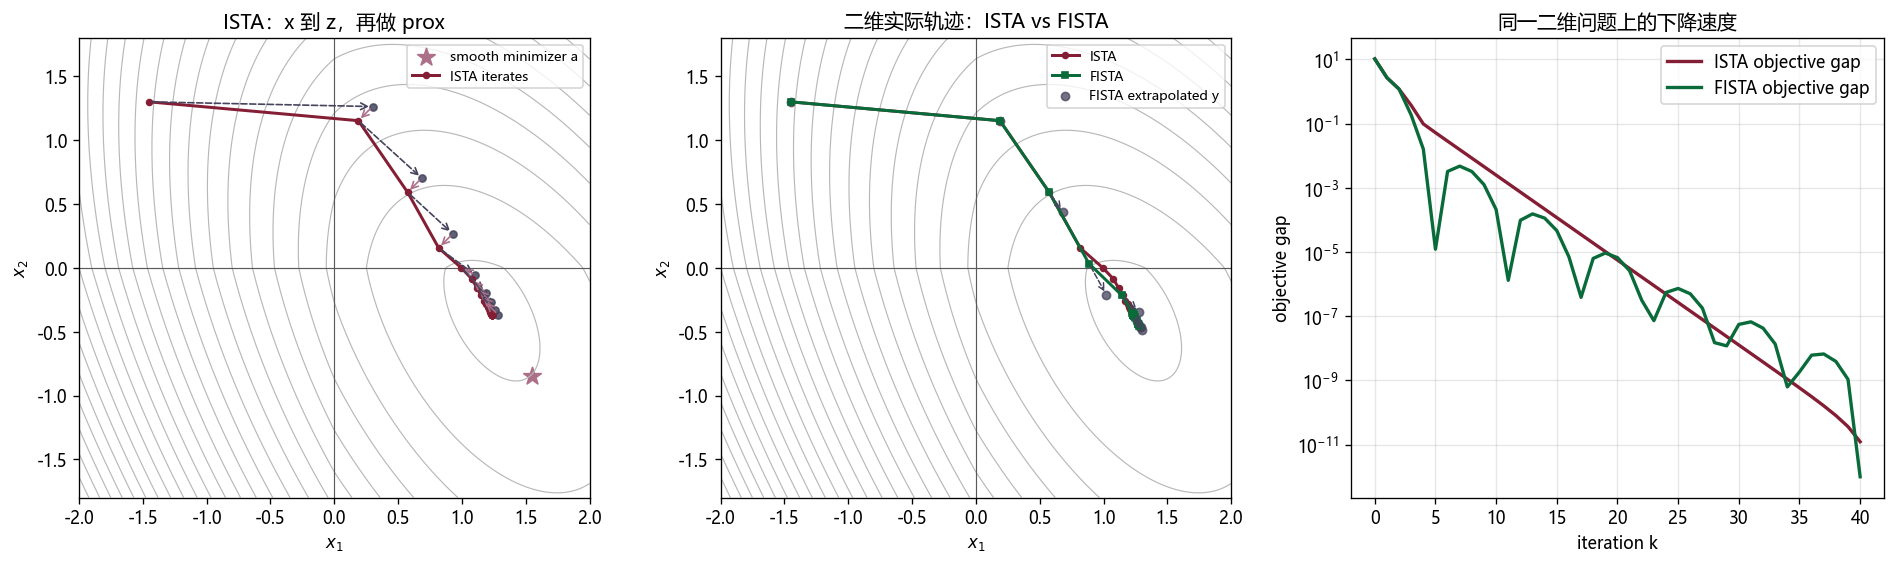

In [6]:
def plot_objective_contours(ax, Q, a, lam, xlim=(-2.0, 2.0), ylim=(-1.8, 1.8), levels=28):
    grid_x = np.linspace(xlim[0], xlim[1], 360)
    grid_y = np.linspace(ylim[0], ylim[1], 360)
    X, Y = np.meshgrid(grid_x, grid_y)
    Z = np.zeros_like(X)
    for i in range(X.shape[0]):
        pts = np.column_stack([X[i], Y[i]])
        diffs = pts - a
        smooth = 0.5 * np.einsum("ij,jk,ik->i", diffs, Q, diffs)
        nonsmooth = lam * (np.abs(pts[:, 0]) + np.abs(pts[:, 1]))
        Z[i] = smooth + nonsmooth
    ax.contour(X, Y, Z, levels=levels, colors="0.72", linewidths=0.7)
    ax.axhline(0, color="0.35", linewidth=0.7)
    ax.axvline(0, color="0.35", linewidth=0.7)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")


xs = result2d["xs"]
zs = result2d["zs"]
xs_fista = result2d_fista["xs"]
ys_fista = result2d_fista["ys"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

plot_objective_contours(axes[0], Q2, a2, lam2)
axes[0].scatter([a2[0]], [a2[1]], color=ORANGE, marker="*", s=120, label="smooth minimizer a")
axes[0].plot(xs[:, 0], xs[:, 1], "o-", color=SHANSHU, linewidth=1.8, markersize=3.5, label="ISTA iterates")
for k in range(min(8, len(zs))):
    xk = xs[k]
    zk = zs[k]
    xnext = xs[k + 1]
    axes[0].annotate("", xy=zk, xytext=xk, arrowprops=dict(arrowstyle="->", color=BLUE, lw=1.0, linestyle="--"))
    axes[0].annotate("", xy=xnext, xytext=zk, arrowprops=dict(arrowstyle="->", color=ORANGE, lw=1.0))
    axes[0].scatter([zk[0]], [zk[1]], color=BLUE, s=18, alpha=0.85)
axes[0].set_title("ISTA：x 到 z，再做 prox")
axes[0].legend(fontsize=8, loc="upper right")

plot_objective_contours(axes[1], Q2, a2, lam2)
axes[1].plot(xs[:, 0], xs[:, 1], "o-", color=SHANSHU, linewidth=1.8, markersize=3.5, label="ISTA")
axes[1].plot(xs_fista[:, 0], xs_fista[:, 1], "s-", color=DEEP_GREEN, linewidth=1.8, markersize=3.2, label="FISTA")
axes[1].scatter(ys_fista[:10, 0], ys_fista[:10, 1], color=BLUE, s=24, alpha=0.75, label="FISTA extrapolated y")
for k in range(min(8, len(ys_fista))):
    axes[1].annotate("", xy=ys_fista[k], xytext=xs_fista[k], arrowprops=dict(arrowstyle="->", color=BLUE, lw=0.9, linestyle="--"))
axes[1].set_title("二维实际轨迹：ISTA vs FISTA")
axes[1].legend(fontsize=8, loc="upper right")

axes[2].semilogy(result2d["F_values"] - min(result2d["F_values"][-1], result2d_fista["F_values"][-1]) + 1e-12,
                 color=SHANSHU, linewidth=2, label="ISTA objective gap")
axes[2].semilogy(result2d_fista["F_values"] - min(result2d["F_values"][-1], result2d_fista["F_values"][-1]) + 1e-12,
                 color=DEEP_GREEN, linewidth=2, label="FISTA objective gap")
axes[2].set_xlabel("iteration k")
axes[2].set_ylabel("objective gap")
axes[2].set_title("同一二维问题上的下降速度")
axes[2].grid(True, which="both", alpha=0.3)
axes[2].legend()

fig.tight_layout()
out = PICS / "chapter8_proximal_gradient_2d_actual_trajectory.png"
fig.savefig(out, bbox_inches="tight")
print(f"alpha = {result2d['alpha']:.4f}, L = {result2d['L']:.4f}, saved to {out}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].semilogy(np.maximum(result2d["grad_maps"], 1e-16), color=DEEP_GREEN, linewidth=2)
axes[0].set_xlabel("iteration k")
axes[0].set_ylabel(r"$\|G_\alpha(x^k)\|$")
axes[0].set_title("近端梯度映射：可作为停止准则")
axes[0].grid(True, which="both", alpha=0.3)

nonzeros = [count_nonzero(x) for x in result2d["xs"]]
axes[1].step(range(len(nonzeros)), nonzeros, where="post", color=SHANSHU, linewidth=2)
axes[1].set_xlabel("iteration k")
axes[1].set_ylabel("number of nonzero coordinates")
axes[1].set_title("稀疏性随迭代变化")
axes[1].set_ylim(-0.1, 2.2)
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
out = PICS / "chapter8_proximal_gradient_2d_mapping_sparsity.png"
fig.savefig(out, bbox_inches="tight")
print(f"saved to {out}")

## 实验 2：为什么要同时优化两类目标

近端梯度法常处理

$$
F(x)=f(x)+g(x).
$$

这不是简单地把两个函数相加，而是在做权衡：

- $f(x)$：通常代表拟合误差、预测误差或业务损失，希望越小越好；
- $g(x)$：通常代表结构偏好，例如稀疏、非负、预算、平滑或低秩。

以 $g(x)=\lambda\|x\|_1$ 为例，$\lambda$ 越大，越强调稀疏性；但过大的 $\lambda$ 可能牺牲拟合效果。

In [7]:
lambda_grid_2d = [0.0, 0.15, 0.42, 0.80, 1.20]
tradeoff_rows = []
tradeoff_results = {}

for lam in lambda_grid_2d:
    res = run_pgd_2d(Q2, a2, lam=lam, x0=(-1.45, 1.30), max_iter=120, tol=1e-12)
    x_final = res["xs"][-1]
    tradeoff_results[lam] = res
    tradeoff_rows.append({
        "lambda": lam,
        "x_final": np.round(x_final, 4),
        "smooth f(x)": quad_l1_f(x_final, Q2, a2),
        "penalty lambda||x||_1": lam * l1_norm(x_final),
        "total F(x)": quad_l1_F(x_final, Q2, a2, lam),
        "nonzeros": count_nonzero(x_final),
        "iterations": len(res["xs"]) - 1,
    })

pd.DataFrame(tradeoff_rows)

,lambda,x_final,smooth f(x),penalty lambda||x||_1,total F(x),nonzeros,iterations
0,0.00,"[1.55, -0.85]",2.194862e-25,0.000000,2.194862e-25,2,96
1,0.15,"[1.4372, -0.6787]",2.130919e-02,0.317382,3.386908e-01,2,95
2,0.42,"[1.2341, -0.3703]",1.670641e-01,0.673872,8.409359e-01,2,93
3,0.80,"[0.9717, -0.0]",5.389625e-01,0.777333,1.316296e+00,1,22
4,1.20,"[0.8383, -0.0]",6.722958e-01,1.006000,1.678296e+00,1,22


saved to c:\Users\zhenw\Nutstore\1\个人信息表\论文阅读计划\latex\slides\优化理论与算法第八章\pics\chapter8_proximal_gradient_tradeoff_lambda.png


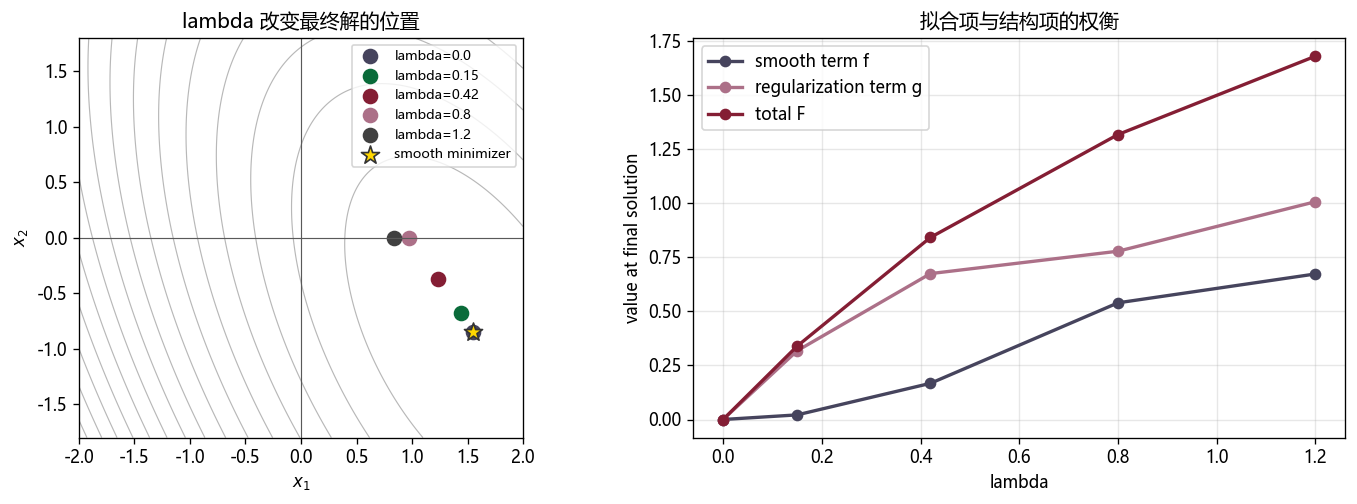

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))

plot_objective_contours(axes[0], Q2, a2, lam=0.0, levels=18)
colors = [BLUE, DEEP_GREEN, SHANSHU, ORANGE, "0.25"]
for color, lam in zip(colors, lambda_grid_2d):
    x_final = tradeoff_results[lam]["xs"][-1]
    axes[0].scatter([x_final[0]], [x_final[1]], s=70, color=color, label=fr"lambda={lam}")
axes[0].scatter([a2[0]], [a2[1]], marker="*", s=130, color="gold", edgecolor="0.2", label="smooth minimizer")
axes[0].set_title("lambda 改变最终解的位置")
axes[0].legend(fontsize=8)

lams = np.array(lambda_grid_2d)
f_vals = np.array([tradeoff_rows[i]["smooth f(x)"] for i in range(len(tradeoff_rows))])
g_vals = np.array([tradeoff_rows[i]["penalty lambda||x||_1"] for i in range(len(tradeoff_rows))])
axes[1].plot(lams, f_vals, "o-", color=BLUE, linewidth=2, label="smooth term f")
axes[1].plot(lams, g_vals, "o-", color=ORANGE, linewidth=2, label="regularization term g")
axes[1].plot(lams, f_vals + g_vals, "o-", color=SHANSHU, linewidth=2, label="total F")
axes[1].set_xlabel("lambda")
axes[1].set_ylabel("value at final solution")
axes[1].set_title("拟合项与结构项的权衡")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

fig.tight_layout()
out = PICS / "chapter8_proximal_gradient_tradeoff_lambda.png"
fig.savefig(out, bbox_inches="tight")
print(f"saved to {out}")

课堂解释：

- 当 `lambda=0` 时，算法只关心光滑项，最终解会更靠近 $a$；
- 当 `lambda` 变大时，$\ell_1$ 正则会把解推向坐标轴，甚至让某些坐标变为 0；
- 这说明近端梯度法不是单纯“求误差最小”，而是在“拟合效果”和“结构偏好”之间找平衡。

## 实验 3：Lasso 的实际效果

现在构造一个稀疏回归问题。真实模型只有少数变量有用：

$$
y=X\beta^\star+\varepsilon,
$$

其中 $\beta^\star$ 大部分分量为 0。我们比较：

- OLS：只最小化平方误差，不鼓励稀疏；
- Lasso：最小化平方误差加 $\ell_1$ 正则；
- ISTA：用近端梯度法求解 Lasso。

目标是观察 Lasso 是否能恢复稀疏结构，并减少无关变量的系数。

In [9]:
def make_sparse_regression(n_train=80, n_test=120, p=30, sparsity=5, noise=0.25, seed=42):
    rng = np.random.default_rng(seed)
    X_train = rng.normal(size=(n_train, p))
    X_test = rng.normal(size=(n_test, p))

    # Standardize using the training design.
    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0) + 1e-12
    X_train = (X_train - mean) / std
    X_test = (X_test - mean) / std

    beta_true = np.zeros(p)
    support = rng.choice(p, size=sparsity, replace=False)
    beta_true[support] = rng.choice([-1, 1], size=sparsity) * rng.uniform(1.0, 2.5, size=sparsity)

    y_train = X_train @ beta_true + noise * rng.normal(size=n_train)
    y_test = X_test @ beta_true + noise * rng.normal(size=n_test)

    y_mean = y_train.mean()
    y_train = y_train - y_mean
    y_test = y_test - y_mean
    return X_train, y_train, X_test, y_test, beta_true, support


def lasso_objective(beta, X, y, lam):
    r = X @ beta - y
    return 0.5 / len(y) * float(r @ r) + lam * l1_norm(beta)


def lasso_grad(beta, X, y):
    return X.T @ (X @ beta - y) / len(y)


def ista_lasso(X, y, lam=0.08, alpha=None, max_iter=2000, tol=1e-8):
    n, p = X.shape
    if alpha is None:
        L = np.linalg.eigvalsh(X.T @ X / n).max()
        alpha = 0.95 / L
    else:
        L = np.linalg.eigvalsh(X.T @ X / n).max()

    beta = np.zeros(p)
    betas = [beta.copy()]
    objectives = [lasso_objective(beta, X, y, lam)]
    grad_maps = []

    for _ in range(max_iter):
        z = beta - alpha * lasso_grad(beta, X, y)
        beta_next = soft_threshold(z, alpha * lam)
        G = (beta - beta_next) / alpha

        betas.append(beta_next.copy())
        objectives.append(lasso_objective(beta_next, X, y, lam))
        grad_maps.append(np.linalg.norm(G))

        beta = beta_next
        if np.linalg.norm(G) <= tol:
            break

    return {
        "beta": beta,
        "betas": np.array(betas),
        "objectives": np.array(objectives),
        "grad_maps": np.array(grad_maps),
        "alpha": alpha,
        "L": L,
    }


def mse(X, y, beta):
    r = X @ beta - y
    return float(np.mean(r ** 2))


X_train, y_train, X_test, y_test, beta_true, support = make_sparse_regression()
lam_lasso = 0.08
start = perf_counter()
ista_res = ista_lasso(X_train, y_train, lam=lam_lasso, max_iter=3000, tol=1e-9)
ista_runtime = perf_counter() - start

beta_lasso = ista_res["beta"]
beta_ols = np.linalg.lstsq(X_train, y_train, rcond=None)[0]

summary_lasso = pd.DataFrame([
    {
        "method": "OLS",
        "train_mse": mse(X_train, y_train, beta_ols),
        "test_mse": mse(X_test, y_test, beta_ols),
        "nonzeros": count_nonzero(beta_ols, tol=1e-6),
        "selected_true_features": len(set(np.flatnonzero(np.abs(beta_ols) > 1e-6)) & set(support)),
    },
    {
        "method": "ISTA-Lasso",
        "train_mse": mse(X_train, y_train, beta_lasso),
        "test_mse": mse(X_test, y_test, beta_lasso),
        "nonzeros": count_nonzero(beta_lasso, tol=1e-6),
        "selected_true_features": len(set(np.flatnonzero(np.abs(beta_lasso) > 1e-6)) & set(support)),
    },
])
add_summary("sparse regression", "ISTA-Lasso", len(ista_res["objectives"]) - 1, ista_runtime, ista_res["objectives"][-1], "synthetic sparse data")
summary_lasso

,method,train_mse,test_mse,nonzeros,selected_true_features
0,OLS,0.049788,0.096853,30,5
1,ISTA-Lasso,0.105601,0.138018,5,5


In [10]:
def fista_lasso(X, y, lam=0.08, alpha=None, max_iter=2000, tol=1e-8, restart=False):
    """FISTA for Lasso, with optional monotone restart."""
    n, p = X.shape
    L = np.linalg.eigvalsh(X.T @ X / n).max()
    if alpha is None:
        alpha = 0.95 / L

    beta_prev = np.zeros(p)
    beta = beta_prev.copy()
    t = 1.0

    betas = [beta.copy()]
    ys = []
    objectives = [lasso_objective(beta, X, y, lam)]
    grad_maps = []
    restarts = []

    for k in range(max_iter):
        momentum = 0.0 if k == 0 else (t_prev - 1.0) / t
        y_extrap = beta + momentum * (beta - beta_prev)
        z = y_extrap - alpha * lasso_grad(y_extrap, X, y)
        beta_next = soft_threshold(z, alpha * lam)

        did_restart = False
        next_obj = lasso_objective(beta_next, X, y, lam)
        if restart and next_obj > objectives[-1]:
            t = 1.0
            y_extrap = beta.copy()
            z = y_extrap - alpha * lasso_grad(y_extrap, X, y)
            beta_next = soft_threshold(z, alpha * lam)
            next_obj = lasso_objective(beta_next, X, y, lam)
            did_restart = True

        G = (beta - beta_next) / alpha
        t_prev = t
        t = 0.5 * (1.0 + np.sqrt(1.0 + 4.0 * t**2))

        ys.append(y_extrap.copy())
        betas.append(beta_next.copy())
        objectives.append(next_obj)
        grad_maps.append(np.linalg.norm(G))
        restarts.append(did_restart)

        beta_prev, beta = beta, beta_next
        if np.linalg.norm(G) <= tol:
            break

    return {
        "beta": beta,
        "betas": np.array(betas),
        "ys": np.array(ys),
        "objectives": np.array(objectives),
        "grad_maps": np.array(grad_maps),
        "restarts": np.array(restarts, dtype=bool),
        "alpha": alpha,
        "L": L,
    }

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
idx = np.arange(len(beta_true))
width = 0.35

axes[0].bar(idx - width / 2, beta_true, width=width, color=DEEP_GREEN, label="true beta")
axes[0].bar(idx + width / 2, beta_ols, width=width, color=ORANGE, alpha=0.8, label="OLS")
axes[0].set_title("OLS：很多无关变量也有非零系数")
axes[0].set_ylabel("coefficient")
axes[0].legend()
axes[0].grid(True, axis="y", alpha=0.25)

axes[1].bar(idx - width / 2, beta_true, width=width, color=DEEP_GREEN, label="true beta")
axes[1].bar(idx + width / 2, beta_lasso, width=width, color=SHANSHU, alpha=0.85, label="ISTA-Lasso")
axes[1].set_title("Lasso：小系数被软阈值压成 0")
axes[1].set_xlabel("feature index")
axes[1].set_ylabel("coefficient")
axes[1].legend()
axes[1].grid(True, axis="y", alpha=0.25)

fig.tight_layout()
out = PICS / "chapter8_proximal_lasso_coefficients.png"
fig.savefig(out, bbox_inches="tight")
print(f"saved to {out}")

ISTA iterations = 80, alpha = 0.3934, saved to c:\Users\zhenw\Nutstore\1\个人信息表\论文阅读计划\latex\slides\优化理论与算法第八章\pics\chapter8_proximal_lasso_convergence_sparsity.png


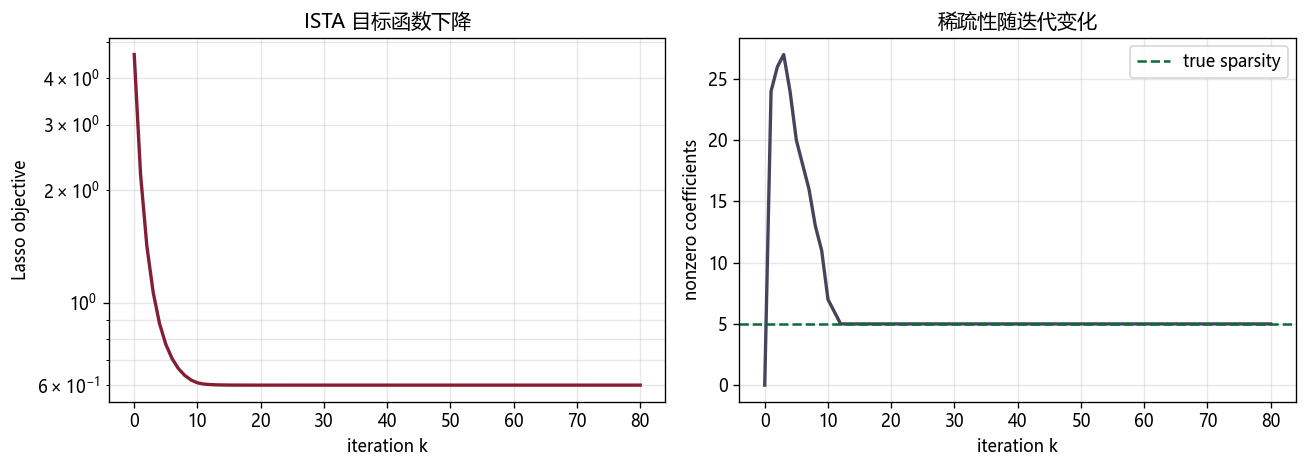

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].semilogy(ista_res["objectives"], color=SHANSHU, linewidth=2)
axes[0].set_xlabel("iteration k")
axes[0].set_ylabel("Lasso objective")
axes[0].set_title("ISTA 目标函数下降")
axes[0].grid(True, which="both", alpha=0.3)

nonzeros_path = [count_nonzero(b, tol=1e-6) for b in ista_res["betas"]]
axes[1].plot(nonzeros_path, color=BLUE, linewidth=2)
axes[1].axhline(np.count_nonzero(beta_true), color=DEEP_GREEN, linestyle="--", label="true sparsity")
axes[1].set_xlabel("iteration k")
axes[1].set_ylabel("nonzero coefficients")
axes[1].set_title("稀疏性随迭代变化")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

fig.tight_layout()
out = PICS / "chapter8_proximal_lasso_convergence_sparsity.png"
fig.savefig(out, bbox_inches="tight")
print(f"ISTA iterations = {len(ista_res['objectives']) - 1}, alpha = {ista_res['alpha']:.4f}, saved to {out}")

这个实验可以用来强调 Lasso 的两个特点：

1. **预测**：它仍然通过平方损失拟合数据；
2. **变量选择**：它通过 $\ell_1$ 正则把小系数压成 0，因此最终模型更稀疏、更容易解释。

课堂上可以让学生观察：OLS 的训练误差可能更低，但它常常保留许多无关变量；Lasso 牺牲一点训练拟合，换来更简洁的模型和更好的结构解释。

## 实验 4：补充一，步长如何影响 ISTA

近端梯度法仍然是一阶方法，步长很重要。对 Lasso 的光滑项

$$
f(\beta)=\frac{1}{2n}\|X\beta-y\|^2,
$$

梯度 Lipschitz 常数为

$$
L=\lambda_{\max}\left(\frac{X^TX}{n}\right).
$$

通常安全选择是 $\alpha\le 1/L$。下面比较几个不同步长。

L = 2.4149, saved to c:\Users\zhenw\Nutstore\1\个人信息表\论文阅读计划\latex\slides\优化理论与算法第八章\pics\chapter8_proximal_lasso_stepsize.png


,alpha factor,alpha,iterations shown,final objective,nonzeros,stable in this run
0,0.25,0.103526,365,0.600779,5,True
1,0.60,0.248463,146,0.600779,5,True
2,1.00,0.414104,84,0.600779,5,True
3,1.40,0.579746,57,0.600779,5,True


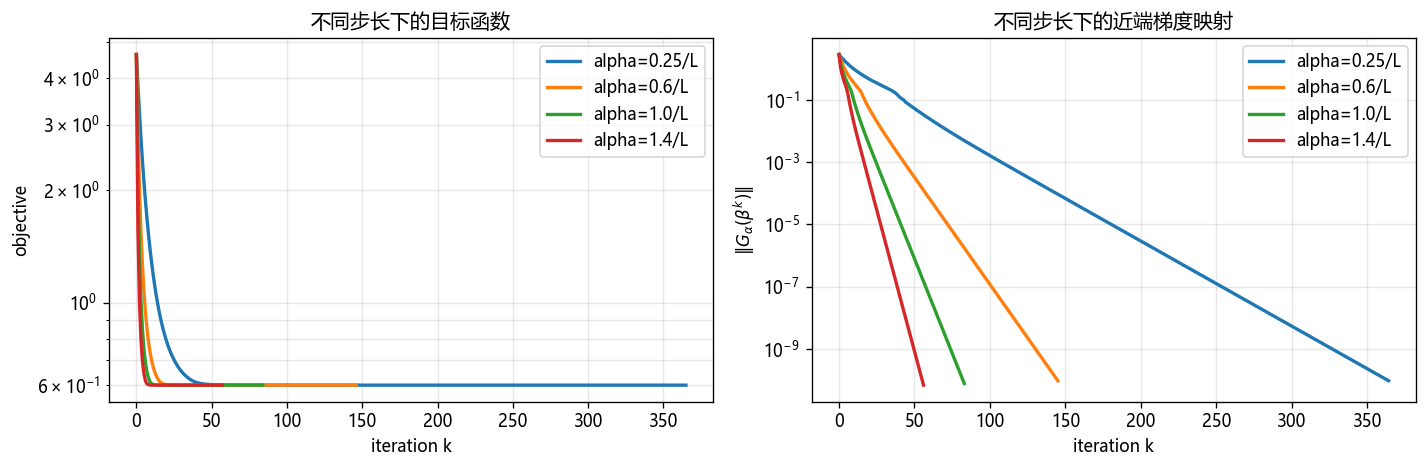

In [12]:
L_lasso = np.linalg.eigvalsh(X_train.T @ X_train / len(y_train)).max()
step_factors = [0.25, 0.60, 1.00, 1.40]
step_rows = []
step_results = {}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for factor in step_factors:
    alpha = factor / L_lasso
    res = ista_lasso(X_train, y_train, lam=lam_lasso, alpha=alpha, max_iter=400, tol=1e-10)
    step_results[factor] = res
    stable = np.all(np.isfinite(res["objectives"])) and res["objectives"][-1] <= res["objectives"][0] * 1.2
    step_rows.append({
        "alpha factor": factor,
        "alpha": alpha,
        "iterations shown": len(res["objectives"]) - 1,
        "final objective": res["objectives"][-1],
        "nonzeros": count_nonzero(res["beta"], tol=1e-6),
        "stable in this run": stable,
    })
    axes[0].semilogy(res["objectives"], linewidth=2, label=fr"alpha={factor}/L")
    axes[1].semilogy(np.maximum(res["grad_maps"], 1e-16), linewidth=2, label=fr"alpha={factor}/L")

axes[0].set_xlabel("iteration k")
axes[0].set_ylabel("objective")
axes[0].set_title("不同步长下的目标函数")
axes[0].grid(True, which="both", alpha=0.3)
axes[0].legend()

axes[1].set_xlabel("iteration k")
axes[1].set_ylabel(r"$\|G_\alpha(\beta^k)\|$")
axes[1].set_title("不同步长下的近端梯度映射")
axes[1].grid(True, which="both", alpha=0.3)
axes[1].legend()

fig.tight_layout()
out = PICS / "chapter8_proximal_lasso_stepsize.png"
fig.savefig(out, bbox_inches="tight")
print(f"L = {L_lasso:.4f}, saved to {out}")
pd.DataFrame(step_rows)

## 实验 5：补充二，正则路径与稀疏性

Lasso 中的 $\lambda$ 决定正则强度。它不是算法参数，而是建模参数：

- $\lambda$ 小：更重视拟合，保留更多变量；
- $\lambda$ 大：更重视稀疏，变量更少，但可能欠拟合。

下面画出不同 $\lambda$ 下的非零变量数量和测试误差。

saved to c:\Users\zhenw\Nutstore\1\个人信息表\论文阅读计划\latex\slides\优化理论与算法第八章\pics\chapter8_proximal_lasso_regularization_path.png


,lambda,train_mse,test_mse,nonzeros,true_selected,false_selected
0,0.010000,0.054045,0.082481,21,5,16
1,0.013984,0.056884,0.081097,19,5,14
2,0.019556,0.061284,0.081172,16,5,11
3,0.027348,0.066844,0.084274,12,5,7
4,0.038244,0.073921,0.091500,7,5,2
5,0.053482,0.083807,0.105842,6,5,1
6,0.074791,0.100832,0.131041,5,5,0
7,0.104591,0.132454,0.176335,5,5,0
8,0.146263,0.194294,0.261546,5,5,0
9,0.204539,0.315230,0.423477,5,5,0


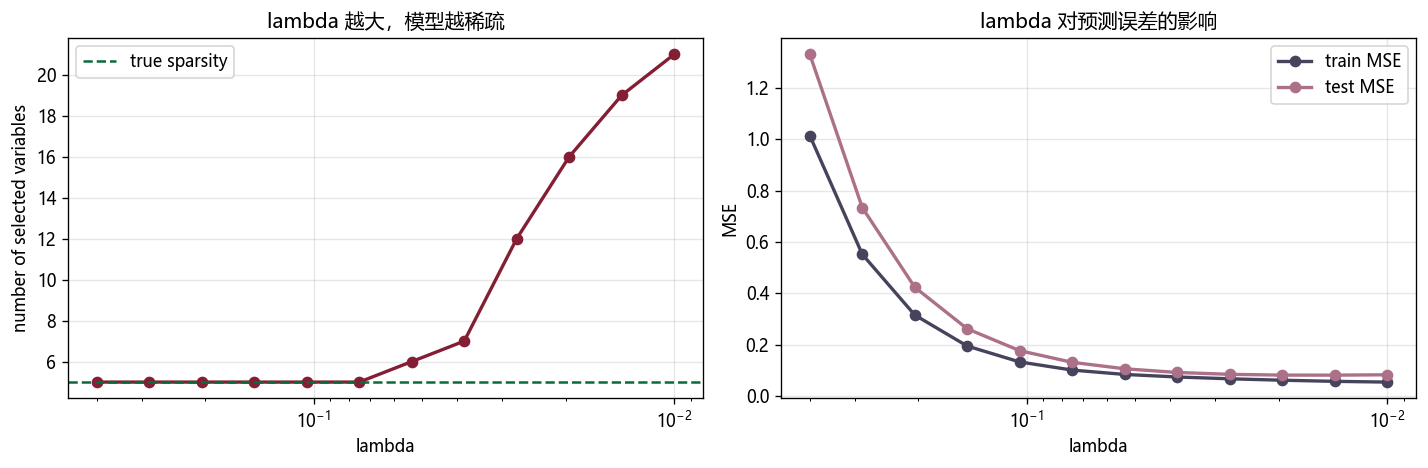

In [13]:
lambda_path = np.geomspace(0.01, 0.40, 12)
path_rows = []
betas_path = []

for lam in lambda_path:
    res = ista_lasso(X_train, y_train, lam=lam, max_iter=3000, tol=1e-9)
    beta = res["beta"]
    betas_path.append(beta)
    selected = set(np.flatnonzero(np.abs(beta) > 1e-6))
    path_rows.append({
        "lambda": lam,
        "train_mse": mse(X_train, y_train, beta),
        "test_mse": mse(X_test, y_test, beta),
        "nonzeros": count_nonzero(beta, tol=1e-6),
        "true_selected": len(selected & set(support)),
        "false_selected": len(selected - set(support)),
    })

path_df = pd.DataFrame(path_rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].semilogx(path_df["lambda"], path_df["nonzeros"], "o-", color=SHANSHU, linewidth=2)
axes[0].axhline(np.count_nonzero(beta_true), color=DEEP_GREEN, linestyle="--", label="true sparsity")
axes[0].invert_xaxis()
axes[0].set_xlabel("lambda")
axes[0].set_ylabel("number of selected variables")
axes[0].set_title("lambda 越大，模型越稀疏")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].semilogx(path_df["lambda"], path_df["train_mse"], "o-", color=BLUE, linewidth=2, label="train MSE")
axes[1].semilogx(path_df["lambda"], path_df["test_mse"], "o-", color=ORANGE, linewidth=2, label="test MSE")
axes[1].invert_xaxis()
axes[1].set_xlabel("lambda")
axes[1].set_ylabel("MSE")
axes[1].set_title("lambda 对预测误差的影响")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

fig.tight_layout()
out = PICS / "chapter8_proximal_lasso_regularization_path.png"
fig.savefig(out, bbox_inches="tight")
print(f"saved to {out}")
path_df

## 实验 6：同一个 Lasso 问题上的 ISTA 与 FISTA

课件中给出的理论结论是：在凸复合问题中，ISTA 的典型速度为 $\mathcal O(1/k)$，FISTA 可以达到 $\mathcal O(1/k^2)$。

不过要注意：这个实验使用的是前面那个小规模稀疏回归问题，变量数不大，Lasso 解也比较快进入稳定稀疏模式。因此它不一定是展示 FISTA 优势的最佳例子，甚至可能出现 FISTA 按停止准则需要更多步的现象。

下面仍然先比较两种算法：

- 每次迭代后的目标函数值；
- 近端梯度映射 $\|G_\alpha(x^k)\|$；
- 达到停止准则所需的迭代次数。

saved to c:\Users\zhenw\Nutstore\1\个人信息表\论文阅读计划\latex\slides\优化理论与算法第八章\pics\chapter8_proximal_ista_vs_fista.png


,method,iterations,runtime_sec,final_objective,nonzeros
0,ISTA,89,0.007060,0.600779,5
1,FISTA,117,0.008115,0.600779,5


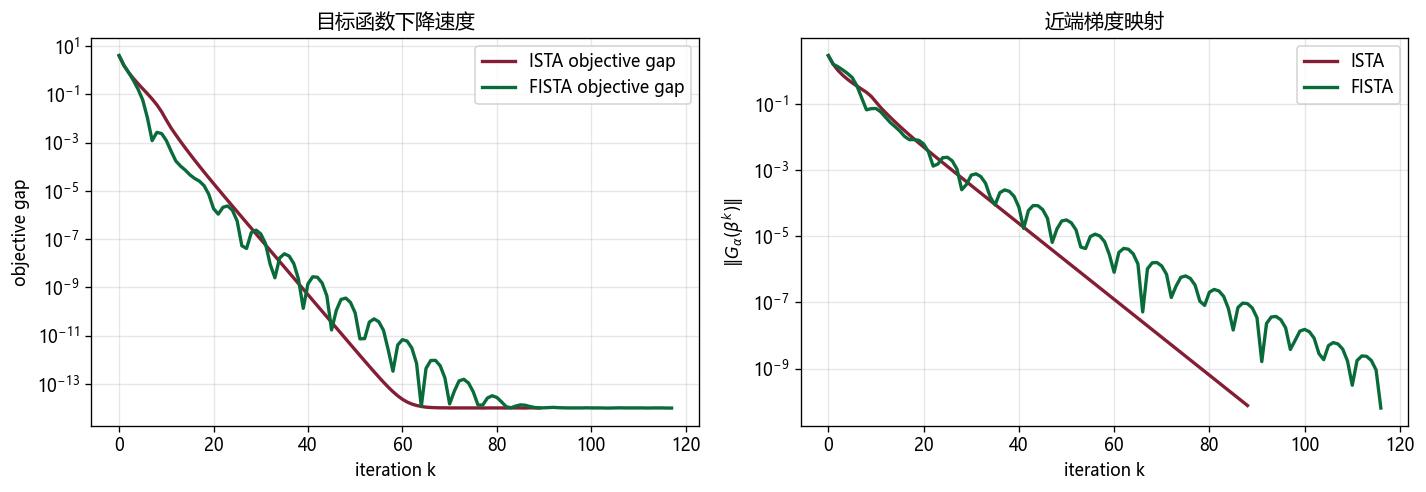

In [14]:
start = perf_counter()
ista_compare = ista_lasso(X_train, y_train, lam=lam_lasso, max_iter=1200, tol=1e-10)
ista_compare_runtime = perf_counter() - start

start = perf_counter()
fista_compare = fista_lasso(X_train, y_train, lam=lam_lasso, max_iter=1200, tol=1e-10)
fista_compare_runtime = perf_counter() - start

best_obj = min(ista_compare["objectives"][-1], fista_compare["objectives"][-1])
ista_gap = ista_compare["objectives"] - best_obj + 1e-14
fista_gap = fista_compare["objectives"] - best_obj + 1e-14

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].semilogy(ista_gap, color=SHANSHU, linewidth=2, label="ISTA objective gap")
axes[0].semilogy(fista_gap, color=DEEP_GREEN, linewidth=2, label="FISTA objective gap")
axes[0].set_xlabel("iteration k")
axes[0].set_ylabel("objective gap")
axes[0].set_title("目标函数下降速度")
axes[0].grid(True, which="both", alpha=0.3)
axes[0].legend()

axes[1].semilogy(np.maximum(ista_compare["grad_maps"], 1e-16), color=SHANSHU, linewidth=2, label="ISTA")
axes[1].semilogy(np.maximum(fista_compare["grad_maps"], 1e-16), color=DEEP_GREEN, linewidth=2, label="FISTA")
axes[1].set_xlabel("iteration k")
axes[1].set_ylabel(r"$\|G_\alpha(\beta^k)\|$")
axes[1].set_title("近端梯度映射")
axes[1].grid(True, which="both", alpha=0.3)
axes[1].legend()

fig.tight_layout()
out = PICS / "chapter8_proximal_ista_vs_fista.png"
fig.savefig(out, bbox_inches="tight")

compare_df = pd.DataFrame([
    {
        "method": "ISTA",
        "iterations": len(ista_compare["objectives"]) - 1,
        "runtime_sec": ista_compare_runtime,
        "final_objective": ista_compare["objectives"][-1],
        "nonzeros": count_nonzero(ista_compare["beta"], tol=1e-6),
    },
    {
        "method": "FISTA",
        "iterations": len(fista_compare["objectives"]) - 1,
        "runtime_sec": fista_compare_runtime,
        "final_objective": fista_compare["objectives"][-1],
        "nonzeros": count_nonzero(fista_compare["beta"], tol=1e-6),
    },
])
add_summary("sparse regression", "FISTA-Lasso", len(fista_compare["objectives"]) - 1, fista_compare_runtime, fista_compare["objectives"][-1], "accelerated proximal gradient")
print(f"saved to {out}")
compare_df

### 为什么实验 6 里 FISTA 可能没有更少步数

如果观察到 FISTA 的迭代步数比 ISTA 更多，不要把它理解为“FISTA 更慢”。主要原因有三点：

1. 这个 Lasso 数据规模较小，而且真解很稀疏，ISTA 已经能很快找到正确的稀疏支撑；
2. FISTA 的外推会让迭代点在最优解附近来回摆动，函数值下降快，但稳定到很小的停止阈值可能反而需要更多步；
3. 这里的停止准则偏向“点是否稳定”，而 FISTA 的优势更多体现在“同样迭代次数下目标函数 gap 更小”。

因此，课堂上可以把实验 6 当作一个提醒：理论加速不等于所有小例子上都表现为更少的停止步数。下面再构造一个对 FISTA 更友好的病态例子。

## 实验 6B：一个 FISTA 明显更快的病态复合优化例子

为了更清楚地看到加速效果，考虑一个高条件数的可分复合问题：

$$
\min_x \frac12\sum_i q_i(x_i-a_i)^2+\lambda\|x\|_1,
\qquad q_i\in[1,1000].
$$

这个问题的曲率差异很大：有些方向很陡，有些方向很平。ISTA 使用固定步长时会被最大曲率限制，在平坦方向上推进很慢；FISTA 的外推更容易体现优势。

这个例子还有一个好处：最优解可以直接写出

$$
x_i^\star=S_{\lambda/q_i}(a_i),
$$

因此我们可以公平比较 objective gap：$F(x^k)-F(x^\star)$。

condition number = 1000, target gap = 3.515e-01, saved to c:\Users\zhenw\Nutstore\1\个人信息表\论文阅读计划\latex\slides\优化理论与算法第八章\pics\chapter8_proximal_fista_faster_ill_conditioned.png


,method,iterations_to_target_gap,gap_at_50,gap_at_200,final_gap
0,ISTA,660,39.459227,4.239093,0.206741
1,FISTA,68,1.476895,0.008088,0.000037


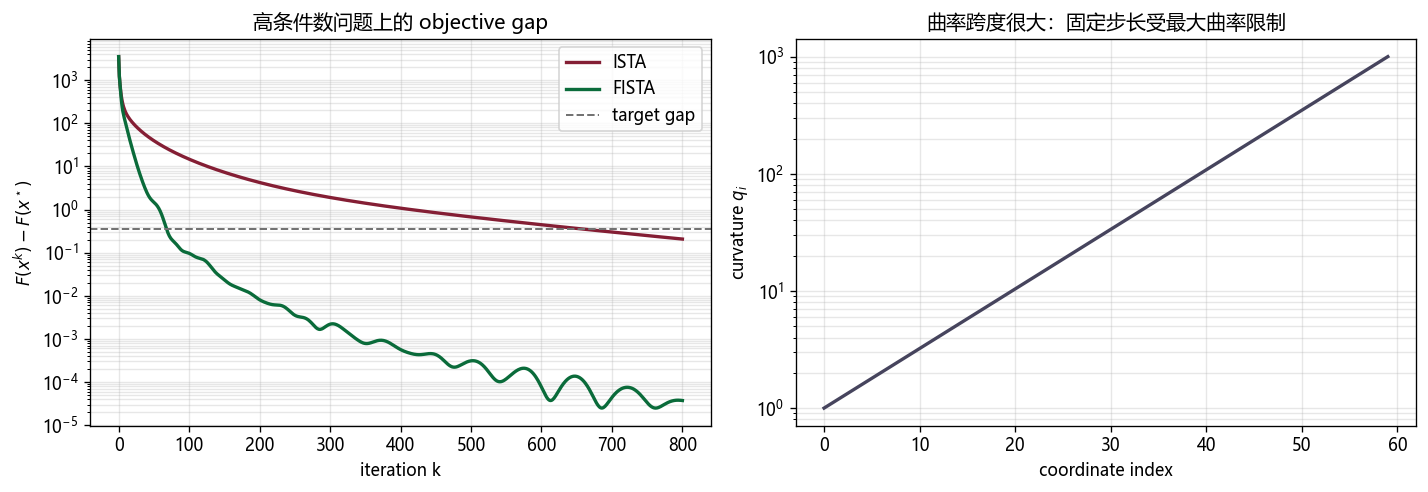

In [15]:
def diag_l1_objective(x, q, a, lam):
    return 0.5 * float(np.sum(q * (x - a) ** 2)) + lam * l1_norm(x)


def run_diag_l1_ista(q, a, lam=0.03, max_iter=800):
    L = float(np.max(q))
    alpha = 0.98 / L
    x = np.zeros_like(a)
    xs = [x.copy()]
    objectives = [diag_l1_objective(x, q, a, lam)]

    for _ in range(max_iter):
        z = x - alpha * q * (x - a)
        x = soft_threshold(z, alpha * lam)
        xs.append(x.copy())
        objectives.append(diag_l1_objective(x, q, a, lam))

    return {"xs": np.array(xs), "objectives": np.array(objectives), "alpha": alpha, "L": L}


def run_diag_l1_fista(q, a, lam=0.03, max_iter=800):
    L = float(np.max(q))
    alpha = 0.98 / L
    x_prev = np.zeros_like(a)
    x = x_prev.copy()
    t = 1.0
    xs = [x.copy()]
    objectives = [diag_l1_objective(x, q, a, lam)]

    for k in range(max_iter):
        beta = 0.0 if k == 0 else (t_prev - 1.0) / t
        y = x + beta * (x - x_prev)
        z = y - alpha * q * (y - a)
        x_next = soft_threshold(z, alpha * lam)
        t_prev = t
        t = 0.5 * (1.0 + np.sqrt(1.0 + 4.0 * t**2))
        x_prev, x = x, x_next
        xs.append(x.copy())
        objectives.append(diag_l1_objective(x, q, a, lam))

    return {"xs": np.array(xs), "objectives": np.array(objectives), "alpha": alpha, "L": L}


def first_below(values, threshold):
    idx = np.flatnonzero(np.asarray(values) <= threshold)
    return int(idx[0]) if len(idx) else None


rng = np.random.default_rng(7)
p_diag = 60
q_diag = np.geomspace(1.0, 1000.0, p_diag)
a_diag = rng.normal(size=p_diag)
lam_diag = 0.03
max_iter_diag = 800

x_star_diag = soft_threshold(a_diag, lam_diag / q_diag)
f_star_diag = diag_l1_objective(x_star_diag, q_diag, a_diag, lam_diag)

ista_diag = run_diag_l1_ista(q_diag, a_diag, lam=lam_diag, max_iter=max_iter_diag)
fista_diag = run_diag_l1_fista(q_diag, a_diag, lam=lam_diag, max_iter=max_iter_diag)

ista_gap_diag = np.maximum(ista_diag["objectives"] - f_star_diag, 1e-16)
fista_gap_diag = np.maximum(fista_diag["objectives"] - f_star_diag, 1e-16)
threshold_diag = 1e-4 * ista_gap_diag[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].semilogy(ista_gap_diag, color=SHANSHU, linewidth=2, label="ISTA")
axes[0].semilogy(fista_gap_diag, color=DEEP_GREEN, linewidth=2, label="FISTA")
axes[0].axhline(threshold_diag, color="0.45", linestyle="--", linewidth=1.2, label="target gap")
axes[0].set_xlabel("iteration k")
axes[0].set_ylabel(r"$F(x^k)-F(x^\star)$")
axes[0].set_title("高条件数问题上的 objective gap")
axes[0].grid(True, which="both", alpha=0.3)
axes[0].legend()

axes[1].plot(q_diag, color=BLUE, linewidth=2)
axes[1].set_yscale("log")
axes[1].set_xlabel("coordinate index")
axes[1].set_ylabel(r"curvature $q_i$")
axes[1].set_title("曲率跨度很大：固定步长受最大曲率限制")
axes[1].grid(True, which="both", alpha=0.3)

fig.tight_layout()
out = PICS / "chapter8_proximal_fista_faster_ill_conditioned.png"
fig.savefig(out, bbox_inches="tight")

faster_df = pd.DataFrame([
    {
        "method": "ISTA",
        "iterations_to_target_gap": first_below(ista_gap_diag, threshold_diag),
        "gap_at_50": ista_gap_diag[50],
        "gap_at_200": ista_gap_diag[200],
        "final_gap": ista_gap_diag[-1],
    },
    {
        "method": "FISTA",
        "iterations_to_target_gap": first_below(fista_gap_diag, threshold_diag),
        "gap_at_50": fista_gap_diag[50],
        "gap_at_200": fista_gap_diag[200],
        "final_gap": fista_gap_diag[-1],
    },
])
add_summary("ill-conditioned diagonal l1", "ISTA", max_iter_diag, np.nan, ista_diag["objectives"][-1], "baseline on high-condition problem")
add_summary("ill-conditioned diagonal l1", "FISTA", max_iter_diag, np.nan, fista_diag["objectives"][-1], "faster objective gap on high-condition problem")
print(f"condition number = {q_diag.max() / q_diag.min():.0f}, target gap = {threshold_diag:.3e}, saved to {out}")
faster_df

## 实验 7：二维图像中观察 FISTA 的外推点

FISTA 的关键不是换了 prox，而是把近端梯度步放在外推点 $y^k$ 上：

$$
y^k=x^k+\beta_k(x^k-x^{k-1}),
\qquad
x^{k+1}=\operatorname{prox}_{\alpha g}\left(y^k-\alpha\nabla f(y^k)\right).
$$

下面回到二维问题，专门画出 $x^k$ 和外推点 $y^k$ 的位置。

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 5.2))
plot_objective_contours(ax, Q2, a2, lam2)

xs_f = result2d_fista["xs"]
ys_f = result2d_fista["ys"]
ax.plot(xs_f[:, 0], xs_f[:, 1], "s-", color=DEEP_GREEN, linewidth=1.8, markersize=3.4, label="FISTA iterates x")
ax.scatter(ys_f[:12, 0], ys_f[:12, 1], color=BLUE, s=28, alpha=0.8, label="extrapolated y")

for k in range(min(10, len(ys_f))):
    ax.annotate("", xy=ys_f[k], xytext=xs_f[k], arrowprops=dict(arrowstyle="->", color=BLUE, lw=1.0, linestyle="--"))
    ax.annotate("", xy=xs_f[k + 1], xytext=ys_f[k], arrowprops=dict(arrowstyle="->", color=ORANGE, lw=1.0))

ax.set_title("FISTA：先外推到 y，再做近端梯度步")
ax.legend(fontsize=8, loc="upper right")
fig.tight_layout()
out = PICS / "chapter8_proximal_fista_extrapolated_points.png"
fig.savefig(out, bbox_inches="tight")
print(f"saved to {out}")

## 实验 8：FISTA 的震荡与 restart

FISTA 使用外推加速，因此函数值不一定每一步都下降。实践中常用 restart 策略：当外推导致目标函数变差时，重置动量，从当前点重新出发。

下面比较：

- ISTA：通常更稳；
- FISTA：下降快，但可能震荡；
- FISTA with restart：在加速和稳定之间折中。

In [ ]:
fista_no_restart = fista_lasso(X_train, y_train, lam=lam_lasso, max_iter=700, tol=1e-10, restart=False)
fista_restart = fista_lasso(X_train, y_train, lam=lam_lasso, max_iter=700, tol=1e-10, restart=True)
ista_restart_compare = ista_lasso(X_train, y_train, lam=lam_lasso, max_iter=700, tol=1e-10)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(ista_restart_compare["objectives"], color=SHANSHU, linewidth=2, label="ISTA")
axes[0].plot(fista_no_restart["objectives"], color=BLUE, linewidth=2, label="FISTA")
axes[0].plot(fista_restart["objectives"], color=DEEP_GREEN, linewidth=2, label="FISTA + restart")
axes[0].set_xlabel("iteration k")
axes[0].set_ylabel("objective")
axes[0].set_title("目标函数曲线")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

obj = fista_no_restart["objectives"]
increases = np.flatnonzero(np.diff(obj) > 1e-10) + 1
axes[1].plot(obj, color=BLUE, linewidth=2, label="FISTA")
axes[1].scatter(increases, obj[increases], color=ORANGE, s=28, label="objective increase")
restart_idx = np.flatnonzero(fista_restart["restarts"]) + 1
axes[1].scatter(restart_idx, fista_restart["objectives"][restart_idx], color=DEEP_GREEN, marker="x", s=40, label="restart")
axes[1].set_xlabel("iteration k")
axes[1].set_ylabel("objective")
axes[1].set_title("震荡点与 restart 点")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

fig.tight_layout()
out = PICS / "chapter8_proximal_fista_restart.png"
fig.savefig(out, bbox_inches="tight")
restart_df = pd.DataFrame([
    {"method": "ISTA", "iterations": len(ista_restart_compare["objectives"]) - 1, "final_objective": ista_restart_compare["objectives"][-1], "objective_increases": 0, "restarts": 0},
    {"method": "FISTA", "iterations": len(fista_no_restart["objectives"]) - 1, "final_objective": fista_no_restart["objectives"][-1], "objective_increases": len(increases), "restarts": 0},
    {"method": "FISTA + restart", "iterations": len(fista_restart["objectives"]) - 1, "final_objective": fista_restart["objectives"][-1], "objective_increases": int(np.sum(np.diff(fista_restart["objectives"]) > 1e-10)), "restarts": int(fista_restart["restarts"].sum())},
])
add_summary("sparse regression", "FISTA-restart", len(fista_restart["objectives"]) - 1, np.nan, fista_restart["objectives"][-1], "monotone restart")
print(f"saved to {out}")
restart_df

## 实验总结

本 Notebook 对应“近端梯度法与 FISTA”课件中的核心问题：

1. **算法如何运行**：二维例子展示了 $x^k\to z^k\to x^{k+1}$ 的两段移动，并对比 ISTA 与 FISTA 的真实轨迹；
2. **prox 如何产生结构**：软阈值会让小系数直接变成 0，因此可以得到稀疏解；
3. **为什么优化两类目标**：光滑项负责拟合，正则项负责结构，两者共同决定最终解；
4. **Lasso 的实际效果**：ISTA-Lasso 可以在预测和变量选择之间折中；
5. **步长和正则参数的影响**：步长影响收敛稳定性，$\lambda$ 影响稀疏性和预测误差；
6. **FISTA 的加速与风险**：FISTA 通常下降更快，但外推可能造成震荡，restart 可以增强稳定性。

课堂提问建议：

- 为什么 Lasso 不是简单地让所有系数变小，而是能让一些系数等于 0？
- 如果 $\lambda=0$，ISTA 会退化成什么算法？
- FISTA 的外推点 $y^k$ 为什么可能带来更快收敛，也可能带来震荡？
- 如果 $g$ 的 prox 很难计算，近端梯度法还适合吗？

In [ ]:
pd.DataFrame(summaries)